# GDV Abschlussanalyse – Angriffsmuster aus der FIFA WM 2022 für Amateurtrainer

## Projektidee

Ich habe die FIFA-WM-2022-Daten gewählt, weil ich Fussball nicht nur als Statistikthema sehe. Ich spiele selbst im Verein und möchte später auch im Trainerbereich arbeiten. Deshalb interessiert mich besonders, was man aus Profidaten für das Training im Amateurfussball ableiten kann.

Die zentrale Frage lautet:

**Welche einfachen Angriffsmuster aus der FIFA WM 2022 können Amateurtrainer für das Training ableiten?**

Dabei geht es nicht darum, Profiteams eins zu eins zu kopieren. Das wäre für einen Amateurverein unrealistisch. Ich suche stattdessen nach einfachen Mustern, die man im Training besprechen kann: Wie schnell kommt ein Team in gefährliche Räume? Wie viele Pässe braucht es bis zum Abschluss? Über welche Wege wird das offensive Drittel erreicht?

Daraus ergeben sich diese Unterfragen:

1. Entstehen Schüsse und Tore eher nach wenigen oder nach vielen Pässen?
2. Welche Passkategorien sind nicht nur häufig, sondern auch effizient?
3. Welche Teams erzeugen nach Entries ins offensive Drittel besonders oft Abschlüsse?
4. Welche Entry-Methode ist für gefährliche Angriffe relevant: langer Pass, kurzer Pass oder Carry?
5. Welche Angriffsmuster sind für Amateurtrainer praktisch verständlich und trainierbar?

Die Analyse ist bewusst deskriptiv. Sie zeigt keine perfekte Taktik und beweist keine Ursache. Sie zeigt aber Muster in den Ballaktionen, die als Trainingsimpulse genutzt werden können.


## 1. Setup

Zuerst werden die Pakete geladen und die Projektpfade gesetzt. Die Farben werden zentral definiert, damit die Abbildungen einheitlich bleiben. Ich nutze bewusst wenige Farben, weil die Plots schnell unübersichtlich werden, wenn zu viele visuelle Reize vorkommen.


In [1]:
from pathlib import Path
import ast
import math
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsbombpy import sb

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "GDV":
    PROJECT_ROOT = PROJECT_ROOT.parent

GDV_DIR = PROJECT_ROOT / "GDV"
DATA_DIR = GDV_DIR / "data"
FIGURE_DIR = GDV_DIR / "figures"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COMPETITION_ID = 43
SEASON_ID = 106

SHOT_SEQUENCES_FILE = DATA_DIR / "gdv_shot_sequences.csv"
ENTRY_POSSESSIONS_FILE = DATA_DIR / "gdv_final_third_entries.csv"
TEAM_SUMMARY_FILE = DATA_DIR / "gdv_team_attack_summary.csv"

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.labelcolor"] = "#222222"
plt.rcParams["xtick.color"] = "#222222"
plt.rcParams["ytick.color"] = "#222222"
plt.rcParams["font.size"] = 10

COLORS = {
    "direct": "#2F6B9A",
    "medium2": "#E69F00",
    "medium": "#66A61E",
    "long": "#7570B3",
    "shot": "#4C78A8",
    "goal": "#E45756",
    "grey": "#D9D9D9",
    "dark": "#222222",
}

print("Projektordner:", PROJECT_ROOT)

C:\Users\tezca\AppData\Roaming\Python\Python311\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\tezca\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Projektordner: c:\Users\tezca\Football


## 2. Hilfsfunktionen

Die Rohdaten bestehen aus einzelnen Events wie Pässen, Carries und Schüssen. Für meine Fragestellung müssen daraus einfach erklärbare Kennzahlen entstehen.

Wichtige Kennzahlen sind zum Beispiel:

- Anzahl erfolgreicher Pässe vor einem Schuss
- Startzone eines Angriffs
- Entry ins offensive Drittel
- Methode des Entries
- Schuss- oder Torfolge nach einem Entry

Ich halte die Metriken bewusst einfach. Für einen Amateurtrainer ist eine klare Kennzahl meistens nützlicher als ein komplexes Modell, das im Bericht schwer erklärbar wäre.


In [2]:
def parse_location(value):
    if isinstance(value, list) and len(value) >= 2:
        return value
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list) and len(parsed) >= 2:
                return parsed
        except Exception:
            return None
    return None


def get_x(value):
    loc = parse_location(value)
    return loc[0] if isinstance(loc, list) else np.nan


def get_y(value):
    loc = parse_location(value)
    return loc[1] if isinstance(loc, list) else np.nan


def event_seconds(row):
    minute = 0 if pd.isna(row.get("minute")) else int(row.get("minute"))
    second = 0 if pd.isna(row.get("second")) else int(row.get("second"))
    return minute * 60 + second


def pass_category(n):
    if pd.isna(n):
        return np.nan
    n = int(n)
    if n <= 3:
        return "0-3"
    if n <= 6:
        return "4-6"
    if n <= 9:
        return "7-9"
    return "10+"

PASS_CATEGORY_ORDER = ["0-3", "4-6", "7-9", "10+"]

PASS_CATEGORY_COLORS = {
    "0-3": COLORS["direct"],
    "4-6": COLORS["medium"],
    "7-9": COLORS["long"],
    "10+": "#6B7280",
}


def start_zone(x):
    if pd.isna(x):
        return "Unknown"
    if x < 40:
        return "Defensives Drittel"
    if x < 80:
        return "Mittelfeld"
    return "Offensives Drittel"


def is_completed_pass(row):
    if row.get("type") != "Pass":
        return False
    outcome = row.get("pass_outcome")
    return pd.isna(outcome) or str(outcome).lower() in ["nan", "none", ""]


def pass_distance(row):
    if pd.isna(row.get("x")) or pd.isna(row.get("y")) or pd.isna(row.get("end_x")) or pd.isna(row.get("end_y")):
        return np.nan
    return float(np.sqrt((row.get("end_x") - row.get("x")) ** 2 + (row.get("end_y") - row.get("y")) ** 2))


def entry_method(row):
    if row is None:
        return "No entry found"
    if row.get("type") in ["Carry", "Carry/Dribbling"]:
        return "Carry"
    if row.get("type") == "Pass":
        dist = pass_distance(row)
        if not pd.isna(dist) and dist >= 30:
            return "Langer Pass"
        return "Kurzer Pass"
    return "Andere"


def extract_formation(value):
    if isinstance(value, dict):
        return value.get("formation")
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, dict):
                return parsed.get("formation")
        except Exception:
            return np.nan
    return np.nan

## 3. Datenaufbereitung

Aus den Eventdaten werden drei Arbeitstabellen erstellt.

Die erste Tabelle enthält alle Schüsse. Für jeden Schuss wird gezählt, wie viele erfolgreiche Pässe in derselben Possession davor gespielt wurden. Dadurch betrachte ich nicht nur Tore, sondern auch allgemein gefährliche Abschlüsse.

Die zweite Tabelle enthält Entries ins offensive Drittel. Ein Entry liegt hier vor, wenn der Ball von ausserhalb in den Bereich `x >= 80` gespielt oder getragen wird. Danach wird geprüft, ob in derselben Possession noch ein Schuss oder ein Tor entsteht.

Die dritte Tabelle fasst Kennzahlen pro Team zusammen. Damit kann ich Teams vergleichen und besser zeigen, welche Teams besonders direkt oder effizient in gefährliche Räume kommen.


In [3]:
def prepare_events(events):
    needed_cols = [
        "id", "index", "period", "timestamp", "minute", "second", "team", "player", "type",
        "possession", "location", "pass_end_location", "carry_end_location", "pass_outcome",
        "shot_outcome", "shot_statsbomb_xg", "play_pattern", "tactics"
    ]
    for col in needed_cols:
        if col not in events.columns:
            events[col] = np.nan

    events = events.sort_values(["period", "index"]).copy()
    events["event_seconds"] = events.apply(event_seconds, axis=1)
    events["x"] = events["location"].apply(get_x)
    events["y"] = events["location"].apply(get_y)
    events["pass_end_x"] = events["pass_end_location"].apply(get_x)
    events["pass_end_y"] = events["pass_end_location"].apply(get_y)
    events["carry_end_x"] = events["carry_end_location"].apply(get_x)
    events["carry_end_y"] = events["carry_end_location"].apply(get_y)
    events["completed_pass"] = events.apply(is_completed_pass, axis=1)
    events["end_x"] = np.where(events["type"] == "Pass", events["pass_end_x"], events["carry_end_x"])
    events["end_y"] = np.where(events["type"] == "Pass", events["pass_end_y"], events["carry_end_y"])
    events["pass_distance"] = events.apply(pass_distance, axis=1)
    return events


def first_final_third_entry(group):
    candidates = group[
        (
            (group["type"].isin(["Pass", "Carry", "Carry/Dribbling"]))
            & (group["x"] < 80)
            & (group["end_x"] >= 80)
        )
    ].copy()
    pass_candidates = candidates[(candidates["type"] != "Pass") | (candidates["completed_pass"])]
    if pass_candidates.empty:
        return None
    return pass_candidates.sort_values("index").iloc[0]


def build_analysis_tables(force_rebuild=False):
    if (
        SHOT_SEQUENCES_FILE.exists()
        and ENTRY_POSSESSIONS_FILE.exists()
        and TEAM_SUMMARY_FILE.exists()
        and not force_rebuild
    ):
        shots = pd.read_csv(SHOT_SEQUENCES_FILE)
        entries = pd.read_csv(ENTRY_POSSESSIONS_FILE)
        team_summary = pd.read_csv(TEAM_SUMMARY_FILE)
        return shots, entries, team_summary

    matches = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
    shot_rows = []
    entry_rows = []
    formation_rows = []

    for match_nr, match in matches.reset_index(drop=True).iterrows():
        match_id = int(match["match_id"])
        match_label = f"{match['home_team']} vs {match['away_team']}"
        print(f"{match_nr + 1}/{len(matches)} {match_label}")

        try:
            events = sb.events(match_id=match_id)
        except Exception as exc:
            print("Could not load match", match_id, exc)
            continue

        events = prepare_events(events)

        starting_xi = events[events["type"] == "Starting XI"].copy()
        for _, row in starting_xi.iterrows():
            formation_rows.append({
                "match_id": match_id,
                "team": row.get("team"),
                "formation": extract_formation(row.get("tactics"))
            })

        formation_map = {
            (item["match_id"], item["team"]): item["formation"]
            for item in formation_rows
        }

        for (team, possession), group in events.groupby(["team", "possession"], dropna=True):
            if pd.isna(team) or pd.isna(possession):
                continue

            group = group.sort_values("index").copy()
            located = group.dropna(subset=["x", "y"])
            if located.empty:
                continue

            start_event = located.iloc[0]
            entry = first_final_third_entry(group)
            already_final_third = start_event["x"] >= 80

            if entry is not None:
                entry_index = entry["index"]
                entry_seconds = entry["event_seconds"]
                entry_x = entry["x"]
                entry_y = entry["y"]
                entry_end_x = entry["end_x"]
                entry_end_y = entry["end_y"]
                method = entry_method(entry)
                before_entry = group[group["index"] <= entry_index]
                passes_to_entry = int(before_entry["completed_pass"].sum())
                time_to_entry = float(entry_seconds - start_event["event_seconds"])
            elif already_final_third:
                entry_index = start_event["index"]
                entry_seconds = start_event["event_seconds"]
                entry_x = start_event["x"]
                entry_y = start_event["y"]
                entry_end_x = start_event["x"]
                entry_end_y = start_event["y"]
                method = "Bereits im offensiven Drittel"
                passes_to_entry = 0
                time_to_entry = 0.0
            else:
                continue

            after_entry = group[group["index"] >= entry_index]
            shots_after_entry = after_entry[after_entry["type"] == "Shot"].copy()
            goals_after_entry = shots_after_entry[shots_after_entry["shot_outcome"].astype(str).str.lower() == "goal"]

            involved_players = group[group["index"] <= entry_index]["player"].dropna().nunique()

            entry_rows.append({
                "match_id": match_id,
                "match_label": match_label,
                "team": team,
                "possession": possession,
                "formation": formation_map.get((match_id, team), np.nan),
                "start_x": start_event["x"],
                "start_y": start_event["y"],
                "start_zone": start_zone(start_event["x"]),
                "entry_x": entry_x,
                "entry_y": entry_y,
                "entry_end_x": entry_end_x,
                "entry_end_y": entry_end_y,
                "entry_method": method,
                "passes_to_entry": passes_to_entry,
                "time_to_entry": time_to_entry,
                "fast_entry": bool(passes_to_entry <= 5 and time_to_entry <= 15),
                "players_before_entry": involved_players,
                "shot_after_entry": int(len(shots_after_entry) > 0),
                "goal_after_entry": int(len(goals_after_entry) > 0),
                "shot_count_after_entry": int(len(shots_after_entry)),
                "goal_count_after_entry": int(len(goals_after_entry)),
                "max_xg_after_entry": shots_after_entry["shot_statsbomb_xg"].max() if len(shots_after_entry) else 0,
                "xg_after_entry": shots_after_entry["shot_statsbomb_xg"].sum() if len(shots_after_entry) else 0,
            })

        shots = events[events["type"] == "Shot"].copy()
        for _, shot in shots.iterrows():
            team = shot.get("team")
            possession = shot.get("possession")
            shot_index = shot.get("index")
            if pd.isna(team) or pd.isna(possession) or pd.isna(shot_index):
                continue

            build = events[
                (events["team"] == team)
                & (events["possession"] == possession)
                & (events["index"] <= shot_index)
            ].sort_values("index").copy()

            located = build.dropna(subset=["x", "y"])
            if located.empty:
                continue

            first_event = located.iloc[0]
            completed_passes = build[build["completed_pass"]]
            players_involved = build["player"].dropna().nunique()
            entry = first_final_third_entry(build)

            if entry is not None:
                before_entry = build[build["index"] <= entry["index"]]
                entry_method_value = entry_method(entry)
                passes_to_entry = int(before_entry["completed_pass"].sum())
                time_to_entry = float(entry["event_seconds"] - first_event["event_seconds"])
            elif first_event["x"] >= 80:
                entry_method_value = "Bereits im offensiven Drittel"
                passes_to_entry = 0
                time_to_entry = 0.0
            else:
                entry_method_value = "No entry found"
                passes_to_entry = np.nan
                time_to_entry = np.nan

            pass_count = int(len(completed_passes))
            duration = float(shot["event_seconds"] - first_event["event_seconds"])
            is_goal = str(shot.get("shot_outcome")).lower() == "goal"

            shot_rows.append({
                "match_id": match_id,
                "match_label": match_label,
                "team": team,
                "opponent": match["away_team"] if team == match["home_team"] else match["home_team"],
                "possession": possession,
                "formation": formation_map.get((match_id, team), np.nan),
                "player": shot.get("player"),
                "minute": shot.get("minute"),
                "second": shot.get("second"),
                "shot_outcome": shot.get("shot_outcome"),
                "is_goal": int(is_goal),
                "shot_xg": shot.get("shot_statsbomb_xg") if not pd.isna(shot.get("shot_statsbomb_xg")) else 0,
                "play_pattern": shot.get("play_pattern"),
                "passes_before_shot": pass_count,
                "pass_category": pass_category(pass_count),
                "duration_seconds": duration,
                "players_involved": players_involved,
                "start_x": first_event["x"],
                "start_y": first_event["y"],
                "start_zone": start_zone(first_event["x"]),
                "shot_x": shot.get("x"),
                "shot_y": shot.get("y"),
                "entry_method": entry_method_value,
                "passes_to_entry": passes_to_entry,
                "time_to_entry": time_to_entry,
                "fast_entry_before_shot": bool((not pd.isna(passes_to_entry)) and passes_to_entry <= 5 and time_to_entry <= 15),
            })

        time.sleep(0.05)

    shots_df = pd.DataFrame(shot_rows)
    entries_df = pd.DataFrame(entry_rows)

    team_summary = (
        entries_df.groupby("team")
        .agg(
            entries=("team", "count"),
            fast_entries=("fast_entry", "sum"),
            shots_after_entry=("shot_after_entry", "sum"),
            goals_after_entry=("goal_after_entry", "sum"),
            avg_players_before_entry=("players_before_entry", "mean"),
        )
        .reset_index()
    )
    team_summary["fast_entry_share"] = team_summary["fast_entries"] / team_summary["entries"]
    team_summary["shot_rate_after_entry"] = team_summary["shots_after_entry"] / team_summary["entries"]
    team_summary["goal_rate_after_entry"] = team_summary["goals_after_entry"] / team_summary["entries"]

    goal_summary = (
        shots_df[shots_df["is_goal"] == 1]
        .groupby("team")
        .agg(
            goals=("is_goal", "sum"),
            avg_passes_before_goal=("passes_before_shot", "mean"),
            avg_goal_duration=("duration_seconds", "mean"),
        )
        .reset_index()
    )
    team_summary = team_summary.merge(goal_summary, on="team", how="left").fillna({"goals": 0})

    shots_df.to_csv(SHOT_SEQUENCES_FILE, index=False)
    entries_df.to_csv(ENTRY_POSSESSIONS_FILE, index=False)
    team_summary.to_csv(TEAM_SUMMARY_FILE, index=False)

    return shots_df, entries_df, team_summary

In [4]:
shots_df, entries_df, team_summary = build_analysis_tables(force_rebuild=False)

shots_df["passes_before_shot"] = pd.to_numeric(shots_df["passes_before_shot"], errors="coerce")
shots_df["is_goal"] = pd.to_numeric(shots_df["is_goal"], errors="coerce").fillna(0).astype(int)
shots_df["pass_category"] = shots_df["passes_before_shot"].apply(pass_category)
shots_df["pass_category"] = pd.Categorical(shots_df["pass_category"], categories=PASS_CATEGORY_ORDER, ordered=True)

if "goal_after_entry" in entries_df.columns:
    entries_df["goal_after_entry"] = pd.to_numeric(entries_df["goal_after_entry"], errors="coerce").fillna(0).astype(int)
if "shot_after_entry" in entries_df.columns:
    entries_df["shot_after_entry"] = pd.to_numeric(entries_df["shot_after_entry"], errors="coerce").fillna(0).astype(int)
if "fast_entry" in entries_df.columns:
    entries_df["fast_entry"] = entries_df["fast_entry"].astype(str).str.lower().isin(["true", "1", "yes"])

print("Analysierte Schüsse:", len(shots_df))
print("Analysierte Tore:", int(shots_df["is_goal"].sum()))
print("Analysierte Entries ins offensive Drittel:", len(entries_df))
print("Teams:", shots_df["team"].nunique())

display(shots_df.head())
display(entries_df.head())


Analysierte Schüsse: 1494
Analysierte Tore: 195
Analysierte Entries ins offensive Drittel: 6593
Teams: 32


,match_id,match_label,team,opponent,possession,formation,player,minute,second,shot_outcome,...,players_involved,start_x,start_y,start_zone,shot_x,shot_y,entry_method,passes_to_entry,time_to_entry,fast_entry_before_shot
0,3857256,Serbia vs Switzerland,Switzerland,Serbia,2,4231,Granit Xhaka,0,18,Blocked,...,7,61.0,40.1,Mittelfeld,96.0,38.8,Langer Pass,4.0,8.0,True
1,3857256,Serbia vs Switzerland,Switzerland,Serbia,2,4231,Breel-Donald Embolo,0,22,Saved,...,8,61.0,40.1,Mittelfeld,113.1,40.7,Langer Pass,4.0,8.0,True
2,3857256,Serbia vs Switzerland,Switzerland,Serbia,2,4231,Granit Xhaka,0,23,Saved,...,8,61.0,40.1,Mittelfeld,103.8,41.9,Langer Pass,4.0,8.0,True
3,3857256,Serbia vs Switzerland,Serbia,Switzerland,11,3412,Nikola Milenković,4,35,Off T,...,2,120.0,0.1,Final third,112.2,36.8,Bereits im offensiven Drittel,0.0,0.0,True
4,3857256,Serbia vs Switzerland,Serbia,Switzerland,24,3412,Andrija Živković,10,5,Post,...,8,52.9,12.7,Mittelfeld,97.8,51.5,Langer Pass,6.0,29.0,False


,match_id,match_label,team,possession,formation,start_x,start_y,start_zone,entry_x,entry_y,...,passes_to_entry,time_to_entry,fast_entry,players_before_entry,shot_after_entry,goal_after_entry,shot_count_after_entry,goal_count_after_entry,max_xg_after_entry,xg_after_entry
0,3857256,Serbia vs Switzerland,Serbia,10,3412,51.7,39.4,Mittelfeld,79.2,54.2,...,11,26.0,False,6,0,0,0,0,0.000000,0.000000
1,3857256,Serbia vs Switzerland,Serbia,11,3412,120.0,0.1,Final third,120.0,0.1,...,0,0.0,True,1,1,0,1,0,0.081609,0.081609
2,3857256,Serbia vs Switzerland,Serbia,20,3412,83.0,9.3,Final third,83.0,9.3,...,0,0.0,True,1,0,0,0,0,0.000000,0.000000
3,3857256,Serbia vs Switzerland,Serbia,21,3412,78.6,0.1,Mittelfeld,78.6,0.1,...,1,0.0,True,1,0,0,0,0,0.000000,0.000000
4,3857256,Serbia vs Switzerland,Serbia,22,3412,117.9,14.1,Final third,117.9,14.1,...,0,0.0,True,1,0,0,0,0,0.000000,0.000000


## 4. Designansatz

Die finale Analyse ist nach einer einfachen Leserführung aufgebaut: zuerst Überblick, dann Effizienz, dann Teamvergleich und am Schluss ein konkretes Beispiel mit Spanien.

Für Kategorien verwende ich Balkendiagramme. Sie passen gut, weil die Werte auf einer gemeinsamen Achse direkt vergleichbar sind. Für Teamvergleiche nutze ich einen sortierten Lollipop-Plot, weil die Rangfolge klar bleibt und weniger Fläche gefüllt wird als bei vielen Balken.

Pitch-Grafiken nutze ich nur dort, wo der Raum auf dem Spielfeld wirklich wichtig ist. Eine frühere Version mit einzelnen Passpfeilen war optisch interessant, aber analytisch schwach. Deshalb wurde sie ersetzt durch eine aggregierte Spielfeldgrafik zu Spaniens Entries ins offensive Drittel. Diese zeigt nicht nur einen Einzelfall, sondern mehrere Angriffe und deren Chance Quality über xG.

Das ist auch die wichtigste Iteration: weniger dekorative Plots, mehr Visualisierungen mit klarer Frage.


In [5]:
def add_value_labels(ax, fmt="{:.0f}", padding=0.01):
    x_min, x_max = ax.get_xlim()
    offset = (x_max - x_min) * padding
    for patch in ax.patches:
        width = patch.get_width()
        if width <= 0:
            continue
        ax.text(
            width + offset,
            patch.get_y() + patch.get_height() / 2,
            fmt.format(width),
            va="center",
            ha="left",
            fontsize=9,
            color=COLORS["dark"],
        )


def percent_text(value):
    return f"{value:.1%}"

## 5. Pässe vor Schüssen und Toren

Der erste Plot beantwortet die Grundfrage: Entstehen gefährliche Abschlüsse eher nach wenigen oder nach vielen Pässen?

Ich vergleiche dafür Schüsse und Tore nach Passkategorien. Nur Tore zu betrachten wäre zu eng, weil Tore selten sind und stärker vom Zufall beeinflusst werden. Schüsse zeigen breiter, wie Teams überhaupt in gefährliche Abschlusspositionen kommen.


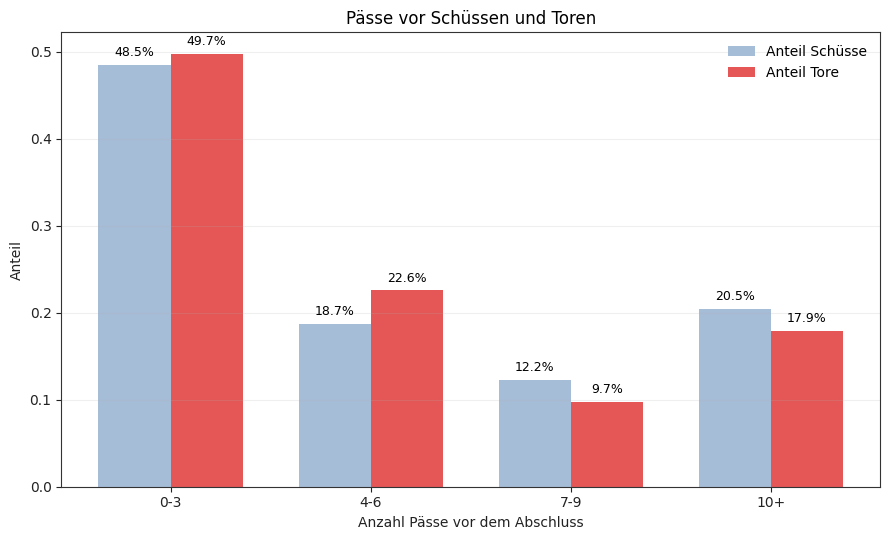

,shots,goals,shot_share,goal_share,conversion_rate
pass_category,,,,,
0-3,725,97,0.485274,0.497436,0.133793
4-6,280,44,0.187416,0.225641,0.157143
7-9,183,19,0.122490,0.097436,0.103825
10+,306,35,0.204819,0.179487,0.114379


In [6]:
category_summary = (
    shots_df.groupby("pass_category")
    .agg(shots=("pass_category", "count"), goals=("is_goal", "sum"))
    .reindex(PASS_CATEGORY_ORDER)
    .fillna(0)
)

category_summary["shot_share"] = category_summary["shots"] / category_summary["shots"].sum()
category_summary["goal_share"] = category_summary["goals"] / category_summary["goals"].sum()
category_summary["conversion_rate"] = category_summary["goals"] / category_summary["shots"]

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(category_summary))
width = 0.36

ax.bar(
    x - width / 2,
    category_summary["shot_share"],
    width,
    label="Anteil Schüsse",
    color="#A6BDD7"
)

ax.bar(
    x + width / 2,
    category_summary["goal_share"],
    width,
    label="Anteil Tore",
    color=COLORS["goal"]
)

for i, row in enumerate(category_summary.itertuples()):
    ax.text(
        i - width / 2,
        row.shot_share + 0.01,
        percent_text(row.shot_share),
        ha="center",
        fontsize=9
    )
    ax.text(
        i + width / 2,
        row.goal_share + 0.01,
        percent_text(row.goal_share),
        ha="center",
        fontsize=9
    )

ax.set_title("Pässe vor Schüssen und Toren")
ax.set_ylabel("Anteil")
ax.set_xlabel("Anzahl Pässe vor dem Abschluss")
ax.set_xticks(x)
ax.set_xticklabels(category_summary.index)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_passes_before_shots_goals.png", dpi=300, bbox_inches="tight")
plt.show()

display(category_summary)

## 6. Effizienz nach Passkategorie

Häufigkeit allein reicht nicht. Eine Passkategorie kann viele Schüsse enthalten, aber trotzdem eine tiefe Torquote haben.

Deshalb berechne ich hier die Torquote pro Passkategorie. So wird sichtbar, ob direkte Angriffe nur häufig vorkommen oder ob sie auch effizienter abgeschlossen werden. Für Trainer ist dieser Unterschied wichtig: Im Training geht es nicht nur darum, oft abzuschliessen, sondern gute Abschlüsse zu erzeugen.


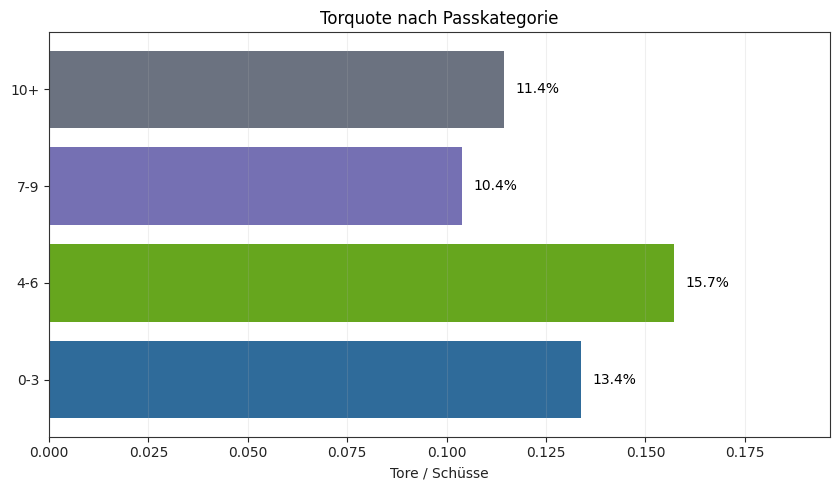

In [7]:
plot_data = category_summary.copy()
fig, ax = plt.subplots(figsize=(8.5, 5))

bars = ax.barh(
    plot_data.index,
    plot_data["conversion_rate"],
    color=[PASS_CATEGORY_COLORS.get(str(c), "#6B7280") for c in plot_data.index]
)

ax.set_title("Torquote nach Passkategorie")
ax.set_xlabel("Tore / Schüsse")
ax.set_ylabel("")
ax.set_xlim(0, max(0.01, plot_data["conversion_rate"].fillna(0).max() * 1.25))
ax.grid(axis="x", alpha=0.2)

for bar, value in zip(bars, plot_data["conversion_rate"].fillna(0)):
    ax.text(value + 0.003, bar.get_y() + bar.get_height()/2, percent_text(value), va="center", fontsize=10)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "02_conversion_by_pass_category.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Was passiert nach dem Eintritt ins offensive Drittel?

Für das Training ist der Weg in gefährliche Räume besonders interessant. Ein Team kann viel Ballbesitz haben, ohne wirklich gefährlich zu werden. Deshalb betrachte ich hier Entries ins offensive Drittel.

Der Plot zeigt Teams, bei denen nach solchen Entries besonders oft ein Abschluss entsteht. Das ist trainingsnah, weil ein Trainer daraus einfache Ziele ableiten kann: schneller erster Pass nach vorne, bessere Unterstützung nach dem Entry und früher Abschluss.


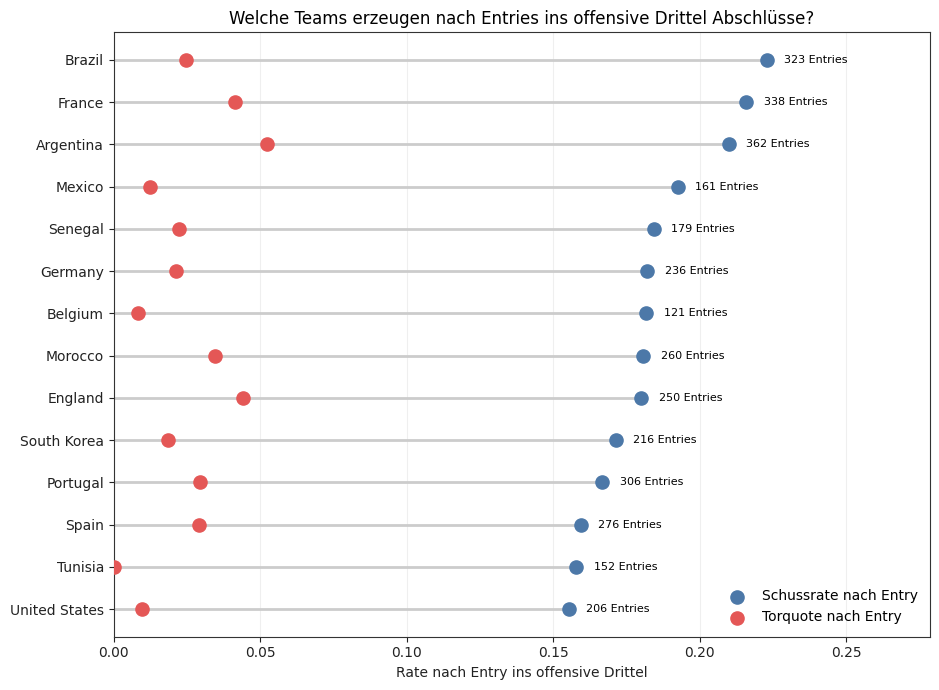

In [8]:
team_entry = team_summary[team_summary["entries"] >= 8].copy()
team_entry = team_entry.sort_values("shot_rate_after_entry", ascending=True).tail(14)

fig, ax = plt.subplots(figsize=(9.5, 7))
y = np.arange(len(team_entry))

ax.hlines(y, 0, team_entry["shot_rate_after_entry"], color="#CCCCCC", linewidth=2)
ax.scatter(team_entry["shot_rate_after_entry"], y, s=90, color=COLORS["shot"], label="Schussrate nach Entry", zorder=3)
ax.scatter(team_entry["goal_rate_after_entry"], y, s=90, color=COLORS["goal"], label="Torquote nach Entry", zorder=3)

for i, row in enumerate(team_entry.itertuples()):
    ax.text(row.shot_rate_after_entry + 0.006, i, f"{row.entries:.0f} Entries", va="center", fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(team_entry["team"])
ax.set_xlabel("Rate nach Entry ins offensive Drittel")
ax.set_title("Welche Teams erzeugen nach Entries ins offensive Drittel Abschlüsse?")
ax.set_xlim(0, max(team_entry["shot_rate_after_entry"].max() * 1.25, 0.1))
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_final_third_entry_outcomes.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Methode des Entries ins offensive Drittel

Hier wird untersucht, wie der Ball ins offensive Drittel kommt. Ich unterscheide lange Pässe, kurze Pässe, Carries und Situationen, in denen die Possession bereits hoch beginnt.

Diese Aufteilung ist praktisch, weil daraus konkrete Trainingsformen entstehen können. Ein Team kann zum Beispiel lange Bälle hinter die Kette trainieren, kurze Kombinationen durch das Zentrum oder Carries in freie Räume.


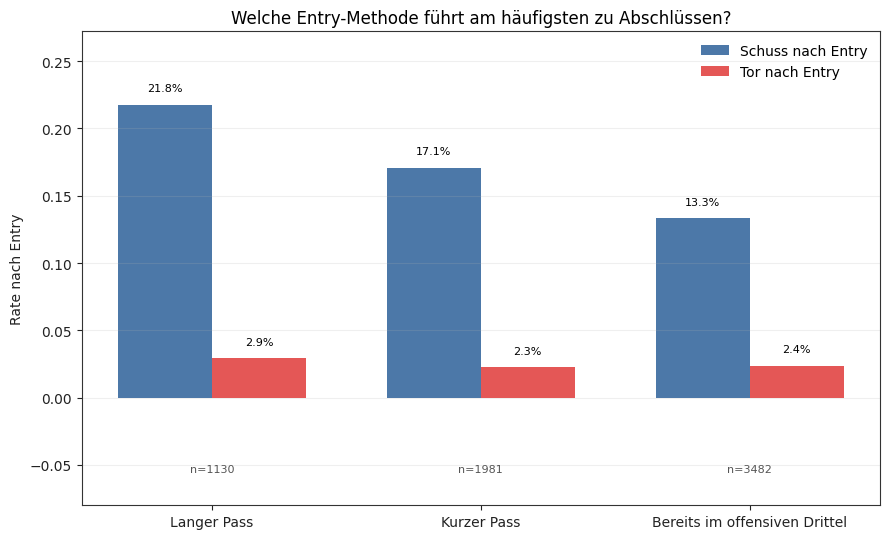

,entry_method,entries,shot_rate,goal_rate
2,Langer Pass,1130,0.217699,0.029204
1,Kurzer Pass,1981,0.170621,0.022716
0,Bereits im offensiven Drittel,3482,0.133257,0.023550


In [9]:
method_summary = (
    entries_df.groupby("entry_method")
    .agg(entries=("entry_method", "count"), shot_rate=("shot_after_entry", "mean"), goal_rate=("goal_after_entry", "mean"))
    .reset_index()
)
method_summary = method_summary[method_summary["entries"] >= 10].sort_values("shot_rate", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(method_summary))
width = 0.35

ax.bar(x - width/2, method_summary["shot_rate"], width, label="Schuss nach Entry", color=COLORS["shot"])
ax.bar(x + width/2, method_summary["goal_rate"], width, label="Tor nach Entry", color=COLORS["goal"])

for i, row in enumerate(method_summary.itertuples()):
    ax.text(i - width/2, row.shot_rate + 0.01, percent_text(row.shot_rate), ha="center", fontsize=8)
    ax.text(i + width/2, row.goal_rate + 0.01, percent_text(row.goal_rate), ha="center", fontsize=8)
    ax.text(i, -0.055, f"n={row.entries}", ha="center", fontsize=8, color="#555555")

ax.set_title("Welche Entry-Methode führt am häufigsten zu Abschlüssen?")
ax.set_ylabel("Rate nach Entry")
ax.set_xticks(x)
ax.set_xticklabels(method_summary["entry_method"], rotation=0)
ax.set_ylim(-0.08, max(method_summary["shot_rate"].max() * 1.25, 0.1))
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_entry_method_outcome.png", dpi=300, bbox_inches="tight")
plt.show()

display(method_summary)

## 9. Startzone von Torangriffen

Dieser Plot zeigt, wo Torangriffe beginnen. Statt eine Heatmap zu verwenden, teile ich das Feld in drei einfache Zonen ein: defensives Drittel, Mittelfeld und offensives Drittel.

Diese Vereinfachung ist bewusst gewählt. Für einen Trainer ist die Frage oft nicht, an welchem exakten Punkt ein Angriff startet, sondern ob das Tor eher nach tiefem Ballgewinn, aus dem Mittelfeld oder nach hohem Ballgewinn entsteht.


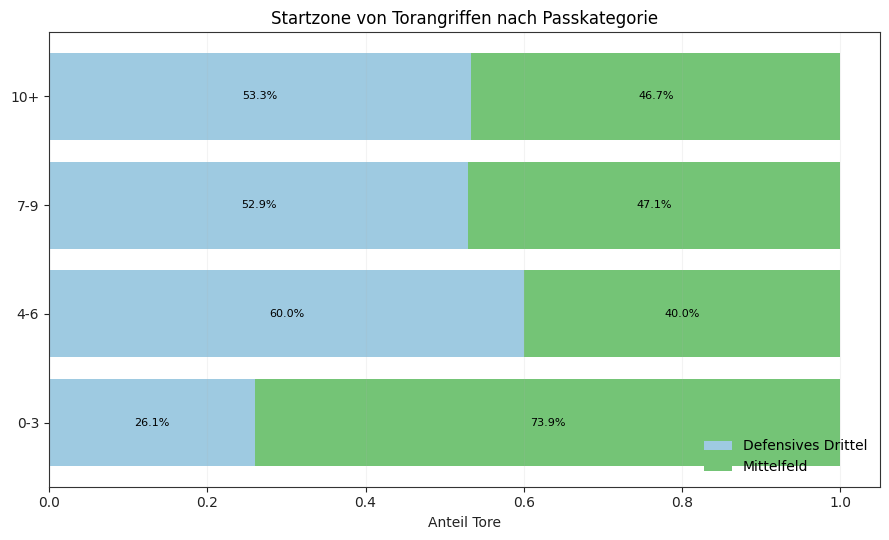

In [10]:
goals = shots_df[shots_df["is_goal"] == 1].copy()
start_matrix = (
    goals.groupby(["pass_category", "start_zone"])
    .size()
    .reset_index(name="count")
)
start_matrix["pass_category"] = pd.Categorical(start_matrix["pass_category"], categories=PASS_CATEGORY_ORDER, ordered=True)
start_matrix = start_matrix.sort_values("pass_category")

pivot = start_matrix.pivot_table(index="pass_category", columns="start_zone", values="count", fill_value=0)
zone_order = ["Defensives Drittel", "Mittelfeld", "Offensives Drittel", "Unknown"]
pivot = pivot.reindex(PASS_CATEGORY_ORDER).fillna(0)
pivot = pivot[[c for c in zone_order if c in pivot.columns]]
share = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(9, 5.5))
left = np.zeros(len(share))
zone_colors = {
    "Defensives Drittel": "#9ECAE1",
    "Mittelfeld": "#74C476",
    "Offensives Drittel": "#FB9A99",
    "Unknown": "#CCCCCC",
}

for zone in share.columns:
    ax.barh(share.index, share[zone], left=left, label=zone, color=zone_colors.get(zone, "#CCCCCC"))
    for i, value in enumerate(share[zone]):
        if value > 0.08:
            ax.text(left[i] + value/2, i, percent_text(value), ha="center", va="center", fontsize=8)
    left += share[zone].values

ax.set_title("Startzone von Torangriffen nach Passkategorie")
ax.set_xlabel("Anteil Tore")
ax.set_ylabel("")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="x", alpha=0.15)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_goal_start_zone.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Team-Ranking: Wer spielt besonders direkt?

Der Teamvergleich macht die Analyse greifbarer. Hier wird pro Team berechnet, wie viele erfolgreiche Pässe im Durchschnitt vor einem Tor gespielt wurden.

Ich verwende einen sortierten Lollipop-Plot, weil man die Rangfolge schnell lesen kann. Die Punktgrösse zeigt zusätzlich, wie viele Tore in die Berechnung eingeflossen sind. Dadurch sieht man nicht nur den Wert, sondern auch, wie stabil der Vergleich ungefähr ist..


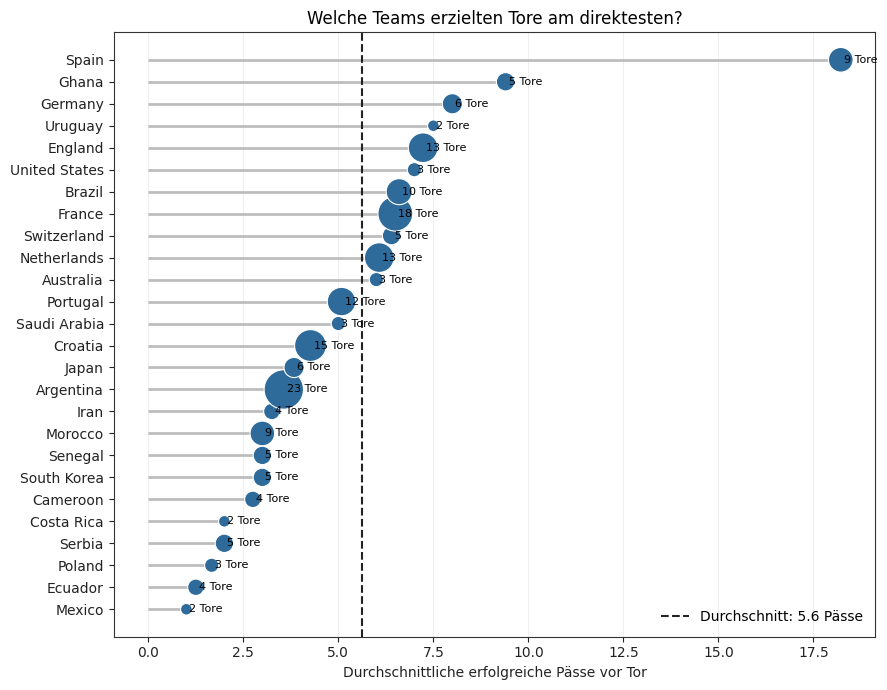

In [11]:
team_goals = (
    goals.groupby("team")
    .agg(goals=("is_goal", "sum"), avg_passes_before_goal=("passes_before_shot", "mean"), avg_duration=("duration_seconds", "mean"))
    .reset_index()
)
team_goals = team_goals[team_goals["goals"] >= 2].sort_values("avg_passes_before_goal", ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(team_goals))

ax.hlines(y, 0, team_goals["avg_passes_before_goal"], color="#BDBDBD", linewidth=2)
ax.scatter(team_goals["avg_passes_before_goal"], y, s=team_goals["goals"] * 35, color=COLORS["direct"], edgecolor="white", linewidth=0.8, zorder=3)
overall_avg = goals["passes_before_shot"].mean()
ax.axvline(overall_avg, color=COLORS["dark"], linestyle="--", linewidth=1.5, label=f"Durchschnitt: {overall_avg:.1f} Pässe")

for i, row in enumerate(team_goals.itertuples()):
    ax.text(row.avg_passes_before_goal + 0.08, i, f"{row.goals:.0f} Tore", va="center", fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(team_goals["team"])
ax.set_xlabel("Durchschnittliche erfolgreiche Pässe vor Tor")
ax.set_title("Welche Teams erzielten Tore am direktesten?")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "06_team_directness_ranking.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Spanien: Entries ins offensive Drittel nach Zonen

Eine einzelne Torsequenz war als Case Study zu schwach, weil sie nur ein Beispiel zeigt. Für die finale Version verwende ich deshalb Spanien als konkreten Team-Use-Case.

Der Plot zeigt, über welche Zonen Spanien ins offensive Drittel gekommen ist und welche Chance Quality daraus entstanden ist. Die grünen Linien zeigen die Angriffe vom Entry bis zum Schuss. Die grüne Fläche zeigt die aufsummierte xG nach Entry-Zone. xG steht für expected goals und beschreibt die geschätzte Torwahrscheinlichkeit eines Schusses.

Diese Visualisierung passt besser zur Fragestellung, weil sie nicht nur eine Szene zeigt, sondern ein wiederkehrendes Angriffsmuster eines bekannten Ballbesitzteams sichtbar macht.


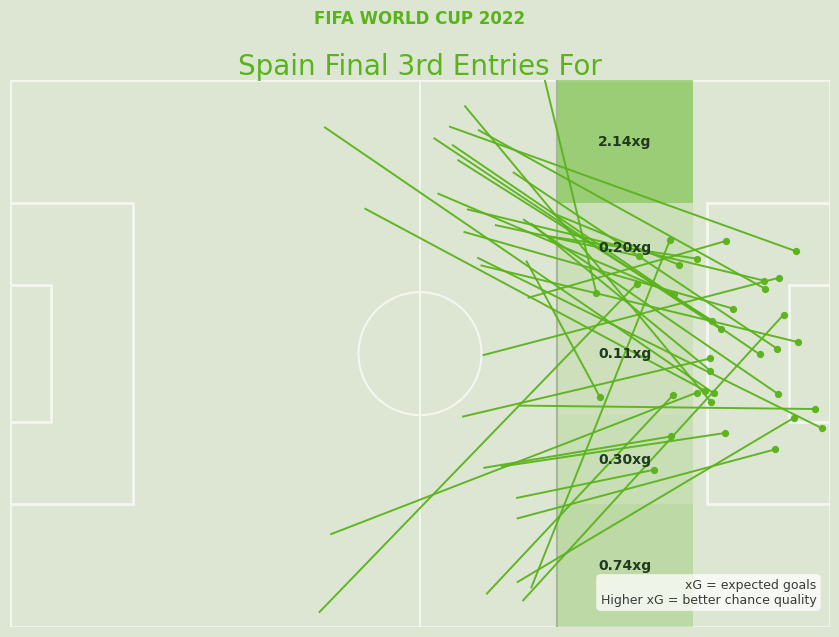

,entries,xg
lane,,
Left wing,17,2.135902
Left half-space,4,0.200203
Center,2,0.109851
Right half-space,5,0.301378
Right wing,7,0.735057


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Arc

team_name = "Spain"
competition_id = 43
season_id = 106

matches = sb.matches(competition_id=competition_id, season_id=season_id)
team_matches = matches[
    (matches["home_team"] == team_name) | (matches["away_team"] == team_name)
].copy()

def lane_name(y):
    if pd.isna(y):
        return np.nan
    if y < 18:
        return "Left wing"
    if y < 31:
        return "Left half-space"
    if y < 49:
        return "Center"
    if y < 62:
        return "Right half-space"
    return "Right wing"

lane_order = ["Left wing", "Left half-space", "Center", "Right half-space", "Right wing"]

lane_y = {
    "Left wing": (0, 18),
    "Left half-space": (18, 31),
    "Center": (31, 49),
    "Right half-space": (49, 62),
    "Right wing": (62, 80)
}

def collect_spain_entry_chances():
    rows = []

    for _, match in team_matches.iterrows():
        match_id = int(match["match_id"])
        events = sb.events(match_id=match_id)
        events = prepare_events(events).sort_values("index").copy()

        spain_events = events[events["team"] == team_name].copy()

        for possession_id, poss in spain_events.groupby("possession"):
            poss = poss.sort_values("index").copy()

            entries = poss[
                poss["type"].isin(["Pass", "Carry"])
                & poss["x"].notna()
                & poss["y"].notna()
                & poss["end_x"].notna()
                & poss["end_y"].notna()
                & (poss["x"] < 80)
                & (poss["end_x"] >= 80)
            ]

            if entries.empty:
                continue

            entry = entries.iloc[0]

            shots_after_entry = poss[
                (poss["type"] == "Shot")
                & poss["x"].notna()
                & poss["y"].notna()
                & (poss["index"] > entry["index"])
            ].copy()

            if shots_after_entry.empty:
                continue

            shot = shots_after_entry.iloc[0]

            shot_xg = shot.get("shot_xg", np.nan)
            if pd.isna(shot_xg):
                shot_xg = shot.get("shot_statsbomb_xg", np.nan)
            if pd.isna(shot_xg):
                shot_xg = 0.0

            rows.append({
                "match_id": match_id,
                "possession": possession_id,
                "entry_start_x": entry["x"],
                "entry_start_y": entry["y"],
                "entry_end_x": entry["end_x"],
                "entry_end_y": entry["end_y"],
                "shot_x": shot["x"],
                "shot_y": shot["y"],
                "shot_xg": float(shot_xg),
                "lane": lane_name(entry["end_y"])
            })

    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.dropna(subset=["lane"]).copy()
    return out

spain_entries = collect_spain_entry_chances()

if spain_entries.empty:
    raise ValueError("Keine Spain final-third entries mit anschliessendem Schuss gefunden.")

lane_summary = (
    spain_entries
    .groupby("lane")
    .agg(
        entries=("lane", "count"),
        total_xg=("shot_xg", "sum"),
        avg_xg=("shot_xg", "mean")
    )
    .reindex(lane_order)
    .fillna(0)
)

def draw_pitch(ax):
    bg = "#DDE6D2"
    line = "#F6F8F1"

    ax.set_facecolor(bg)
    ax.add_patch(Rectangle((0, 0), 120, 80, fill=False, edgecolor=line, linewidth=2))
    ax.plot([60, 60], [0, 80], color=line, linewidth=1.5)
    ax.add_patch(Arc((60, 40), 18, 18, theta1=0, theta2=360, color=line, linewidth=1.4))

    ax.add_patch(Rectangle((102, 18), 18, 44, fill=False, edgecolor=line, linewidth=2))
    ax.add_patch(Rectangle((114, 30), 6, 20, fill=False, edgecolor=line, linewidth=2))
    ax.add_patch(Rectangle((0, 18), 18, 44, fill=False, edgecolor=line, linewidth=2))
    ax.add_patch(Rectangle((0, 30), 6, 20, fill=False, edgecolor=line, linewidth=2))

    ax.axvline(80, color="#9CAE8D", linewidth=1.6)

    ax.set_xlim(0, 120)
    ax.set_ylim(80, 0)
    ax.set_aspect("equal")
    ax.axis("off")

fig, ax = plt.subplots(figsize=(9.5, 7.2), facecolor="#DDE6D2")
draw_pitch(ax)

green = "#56B51F"
dark = "#203A1F"
max_xg = max(lane_summary["total_xg"].max(), 0.01)

for lane in lane_order:
    y0, y1 = lane_y[lane]
    total_xg = lane_summary.loc[lane, "total_xg"]
    entries = int(lane_summary.loc[lane, "entries"])
    avg_xg = lane_summary.loc[lane, "avg_xg"]
    alpha = 0.12 + 0.43 * (total_xg / max_xg)

    ax.add_patch(
        Rectangle(
            (80, y0),
            22,
            y1 - y0,
            facecolor=green,
            edgecolor="none",
            alpha=alpha
        )
    )

    y_mid = (y0 + y1) / 2
    ax.text(
        91,
        y_mid - 2.7,
        f"{total_xg:.2f} xG",
        ha="center",
        va="center",
        fontsize=10.5,
        color=dark,
        fontweight="bold"
    )
    ax.text(
        91,
        y_mid + 2.8,
        f"{entries} entries | Ø {avg_xg:.2f} xG",
        ha="center",
        va="center",
        fontsize=8.5,
        color=dark
    )

# Linien nur leicht transparent, damit der Plot nicht überladen wirkt
for _, row in spain_entries.iterrows():
    ax.plot(
        [row["entry_start_x"], row["shot_x"]],
        [row["entry_start_y"], row["shot_y"]],
        color=green,
        linewidth=1.25,
        alpha=0.65
    )
    ax.scatter(row["shot_x"], row["shot_y"], s=18, color=green, alpha=0.85)

ax.text(
    60,
    -8.5,
    "FIFA WORLD CUP 2022",
    ha="center",
    va="center",
    fontsize=12,
    color=green,
    fontweight="bold"
)

ax.text(
    60,
    -2,
    "Spain final-third entries and chance quality",
    ha="center",
    va="center",
    fontsize=19,
    color=green
)

ax.text(
    60,
    84,
    "Darker zones show more total xG after entries from that lane. Lines connect the entry to the following shot.",
    ha="center",
    va="center",
    fontsize=10,
    color=dark
)

ax.text(
    118,
    77,
    "xG = expected goals\nhigher xG = better chance quality",
    ha="right",
    va="bottom",
    fontsize=9,
    color=dark,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.78, boxstyle="round,pad=0.35")
)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "07_spain_final_third_entries_for.png", dpi=300, bbox_inches="tight")
plt.show()

display(lane_summary)


## 12. Formation als Kontext

Die Formation wird nur als Zusatzkontext betrachtet. Ich nutze sie nicht als Hauptbeweis, weil Eventdaten keine vollständigen Laufwege und keine echte Staffelung ohne Ball zeigen.

Wenn genügend Formation-Daten vorhanden sind, zeigt der Plot, bei welchen Formationen nach Entries ins offensive Drittel häufiger Schüsse oder Tore entstehen. Die Interpretation bleibt vorsichtig und beschreibend.


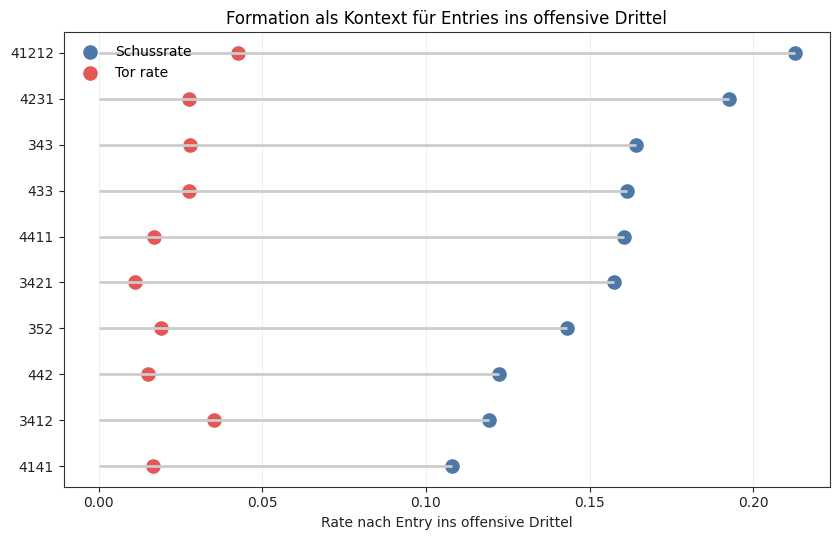

,formation,entries,fast_entry_share,shot_rate,goal_rate
6,4141,241,0.800830,0.107884,0.016598
4,3412,369,0.777778,0.119241,0.035230
3,442,801,0.841448,0.122347,0.014981
1,352,524,0.816794,0.143130,0.019084
5,3421,362,0.861878,0.157459,0.011050
8,4411,237,0.797468,0.160338,0.016878
2,433,2021,0.759030,0.161306,0.027709
0,343,323,0.829721,0.164087,0.027864
7,4231,1668,0.778777,0.192446,0.027578
9,41212,47,0.829787,0.212766,0.042553


In [13]:
formation_data = entries_df.dropna(subset=["formation"]).copy()
formation_profile = (
    formation_data.groupby("formation")
    .agg(entries=("formation", "count"), fast_entry_share=("fast_entry", "mean"), shot_rate=("shot_after_entry", "mean"), goal_rate=("goal_after_entry", "mean"))
    .reset_index()
)
formation_profile = formation_profile[formation_profile["entries"] >= 15].sort_values("shot_rate", ascending=True)

if not formation_profile.empty:
    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    y = np.arange(len(formation_profile))
    ax.hlines(y, 0, formation_profile["shot_rate"], color="#CCCCCC", linewidth=2)
    ax.scatter(formation_profile["shot_rate"], y, s=90, color=COLORS["shot"], label="Schussrate")
    ax.scatter(formation_profile["goal_rate"], y, s=90, color=COLORS["goal"], label="Tor rate")
    ax.set_yticks(y)
    ax.set_yticklabels(formation_profile["formation"].astype(str))
    ax.set_xlabel("Rate nach Entry ins offensive Drittel")
    ax.set_title("Formation als Kontext für Entries ins offensive Drittel")
    ax.legend(frameon=False)
    ax.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "08_formation_context_optional.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Nicht genügend Formation-Daten für einen stabilen Formation-Plot.")

display(formation_profile)

## 13. Evaluation und Iteration

Für GDV reicht es nicht, am Ende einfach fertige Plots zu zeigen. Wichtig ist auch, ob die Visualisierungen verständlich sind und ob sie nach Feedback verbessert wurden.

In früheren Versionen wurden Heatmaps, viele Passpfeile und breite Scatterplots ausprobiert. Diese Plots sahen teilweise interessant aus, waren aber schwer zu lesen oder beantworteten die Fragestellung nicht direkt genug. Deshalb wurden sie reduziert und durch klarere Vergleiche ersetzt.

Für eine kurze formative Evaluation können drei fussballinteressierte Personen die finalen Plots ansehen und einfache Aufgaben lösen:

1. Welche Passkategorie kommt bei Schüssen und Toren am häufigsten vor?
2. Welche Passkategorie wirkt am effizientesten?
3. Welche Teams erzeugen nach Entries ins offensive Drittel oft Abschlüsse?
4. Welche Entry-Methode ist am verständlichsten?
5. Ist der Spanien-Plot verständlich und erkennt man, was xG bedeutet?

Das Feedback wird genutzt, um Titel, Legenden und Begleittexte zu verbessern. Die Datenanalyse selbst wird dadurch nicht künstlich verändert. Es geht bei der Evaluation darum, die Kommunikation der Ergebnisse klarer zu machen.


## 14. Zusammenfassung

Die Analyse zeigt keine einzelne perfekte Angriffstaktik. Das wäre mit Eventdaten auch nicht seriös. Stattdessen werden einfache Angriffsmuster sichtbar, die für Amateurtrainer interessant sind.

Die wichtigsten Erkenntnisse sind:

- Gefährliche Abschlüsse entstehen nicht nur nach langen Ballbesitzphasen.
- Die Kombination aus Passanzahl und Torquote ist aussagekräftiger als nur die Anzahl der Pässe.
- Entries ins offensive Drittel sind ein guter Zwischenpunkt, um gefährliche Angriffe zu untersuchen.
- Lange Pässe, kurze Kombinationen und Carries können alle relevant sein. Entscheidend ist, was nach dem Entry passiert.
- Teamvergleiche zeigen unterschiedliche Spielstile.
- Der Spanien-Plot zeigt, wie ein Ballbesitzteam über bestimmte Zonen ins offensive Drittel kommt und daraus Chancen erzeugt.

Für den Amateurfussball bedeutet das: Man sollte nicht versuchen, Profisysteme direkt zu kopieren. Sinnvoller ist es, einfache Prinzipien zu trainieren: schnell in gefährliche Räume kommen, nach Ballgewinn zielstrebig bleiben, mehrere Spieler in den Angriff bringen und Abschlüsse früher suchen.


In [14]:
print("Finale GDV-Zusammenfassung")
print("-----------------")
print(f"Analysierte Schüsse: {len(shots_df)}")
print(f"Analysierte Tore: {int(shots_df['is_goal'].sum())}")
print(f"Analysierte Entries ins offensive Drittel: {len(entries_df)}")
print()
print("Zusammenfassung nach Passkategorie:")
display(category_summary)
print()
print("Teams mit den höchsten Schussraten nach Entry ins offensive Drittel:")
display(
    team_summary[team_summary["entries"] >= 8]
    .sort_values("shot_rate_after_entry", ascending=False)
    [["team", "entries", "fast_entry_share", "shot_rate_after_entry", "goal_rate_after_entry", "avg_players_before_entry"]]
    .head(10)
)
print()
print("Gespeicherte finale Figuren:")
for path in sorted(FIGURE_DIR.glob("gdv_final_*.png")):
    print(path.name)


Finale GDV-Zusammenfassung
-----------------
Analysierte Schüsse: 1494
Analysierte Tore: 195
Analysierte Entries ins offensive Drittel: 6593

Zusammenfassung nach Passkategorie:


,shots,goals,shot_share,goal_share,conversion_rate
pass_category,,,,,
0-3,725,97,0.485274,0.497436,0.133793
4-6,280,44,0.187416,0.225641,0.157143
7-9,183,19,0.122490,0.097436,0.103825
10+,306,35,0.204819,0.179487,0.114379



Teams mit den höchsten Schussraten nach Entry ins offensive Drittel:


,team,entries,fast_entry_share,shot_rate_after_entry,goal_rate_after_entry,avg_players_before_entry
3,Brazil,323,0.773994,0.222910,0.024768,2.637771
11,France,338,0.724852,0.215976,0.041420,2.831361
0,Argentina,362,0.795580,0.209945,0.052486,2.558011
16,Mexico,161,0.745342,0.192547,0.012422,2.503106
23,Senegal,179,0.877095,0.184358,0.022346,2.094972
12,Germany,236,0.783898,0.182203,0.021186,2.364407
2,Belgium,121,0.710744,0.181818,0.008264,2.950413
17,Morocco,260,0.826923,0.180769,0.034615,2.176923
10,England,250,0.736000,0.180000,0.044000,2.892000
25,South Korea,216,0.726852,0.171296,0.018519,2.759259



Gespeicherte finale Figuren:
gdv_final_01_4_5_pass_beobachtung.png
gdv_final_01_4_5_pass_observation.png
gdv_final_01_passes_before_shots_goals.png
gdv_final_01_trainerregel_passes.png
gdv_final_02_attack_categories.png
gdv_final_02_conversion_by_pass_category.png
gdv_final_03_fast_entries_outcomes.png
gdv_final_03_final_third_entry_outcomes.png
gdv_final_04_entry_method_efficiency.png
gdv_final_04_entry_method_outcome.png
gdv_final_05_goal_start_zone.png
gdv_final_05_players_involved_efficiency.png
gdv_final_05_start_zone_by_attack_type.png
gdv_final_06_formation_entry_profile.png
gdv_final_06_players_involved_efficiency.png
gdv_final_06_team_directness_ranking.png
gdv_final_07_4_5_pass_case_study.png
gdv_final_07_direct_goal_case_study.png
gdv_final_07_formation_entry_profile.png
gdv_final_07_team_directness_ranking.png
gdv_final_08_formation_context_optional.png
gdv_final_08_team_directness_ranking.png
gdv_final_08_trainer_rule_case_study.png
gdv_final_09_trainer_rule_case_study.pn